C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


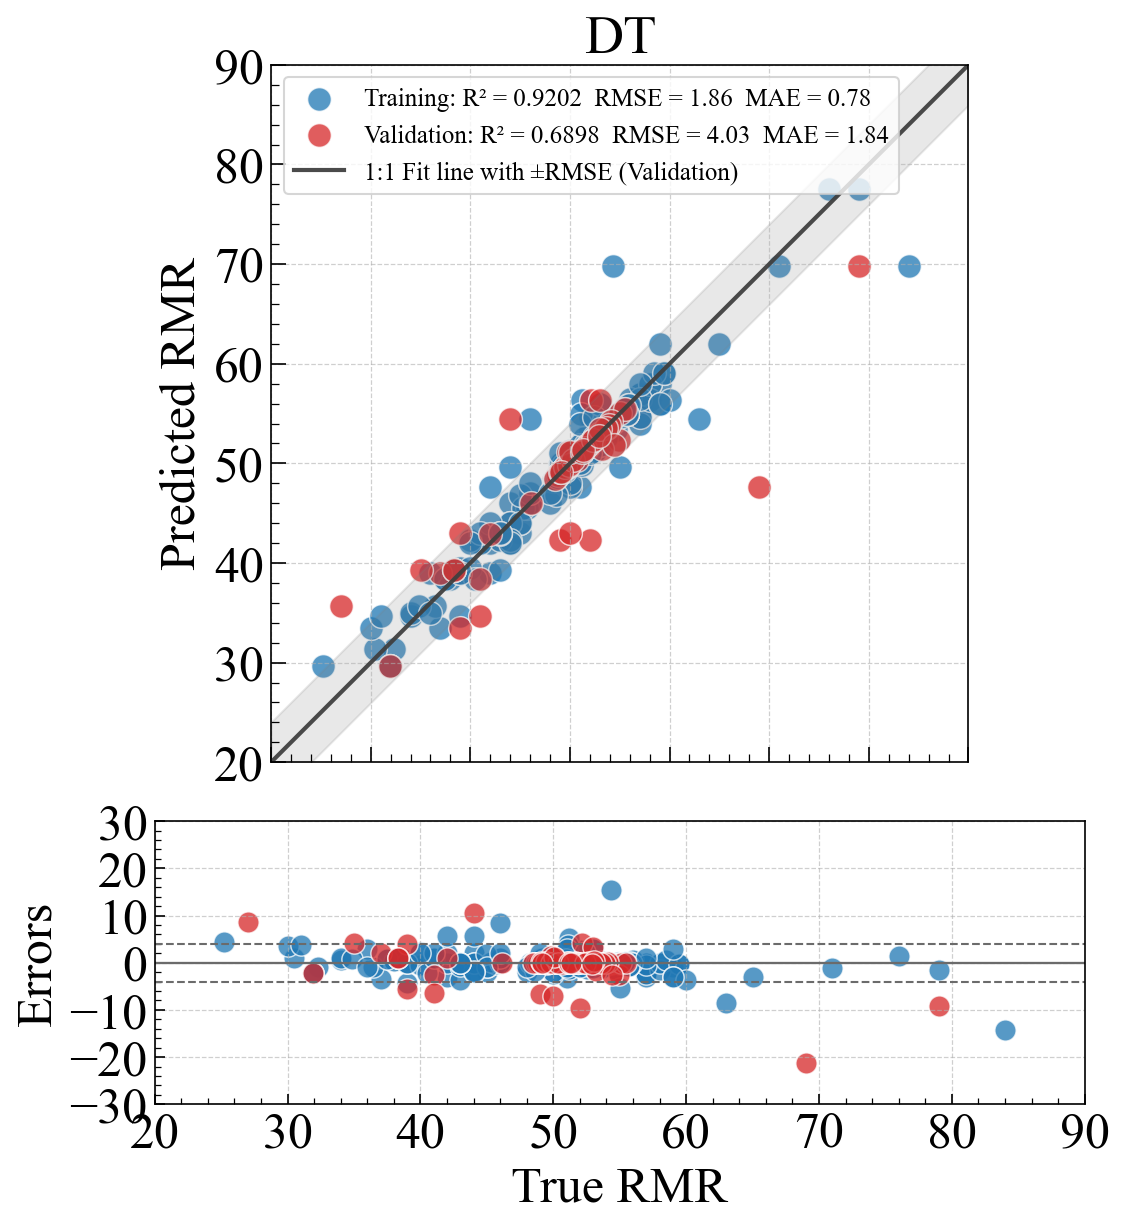

C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


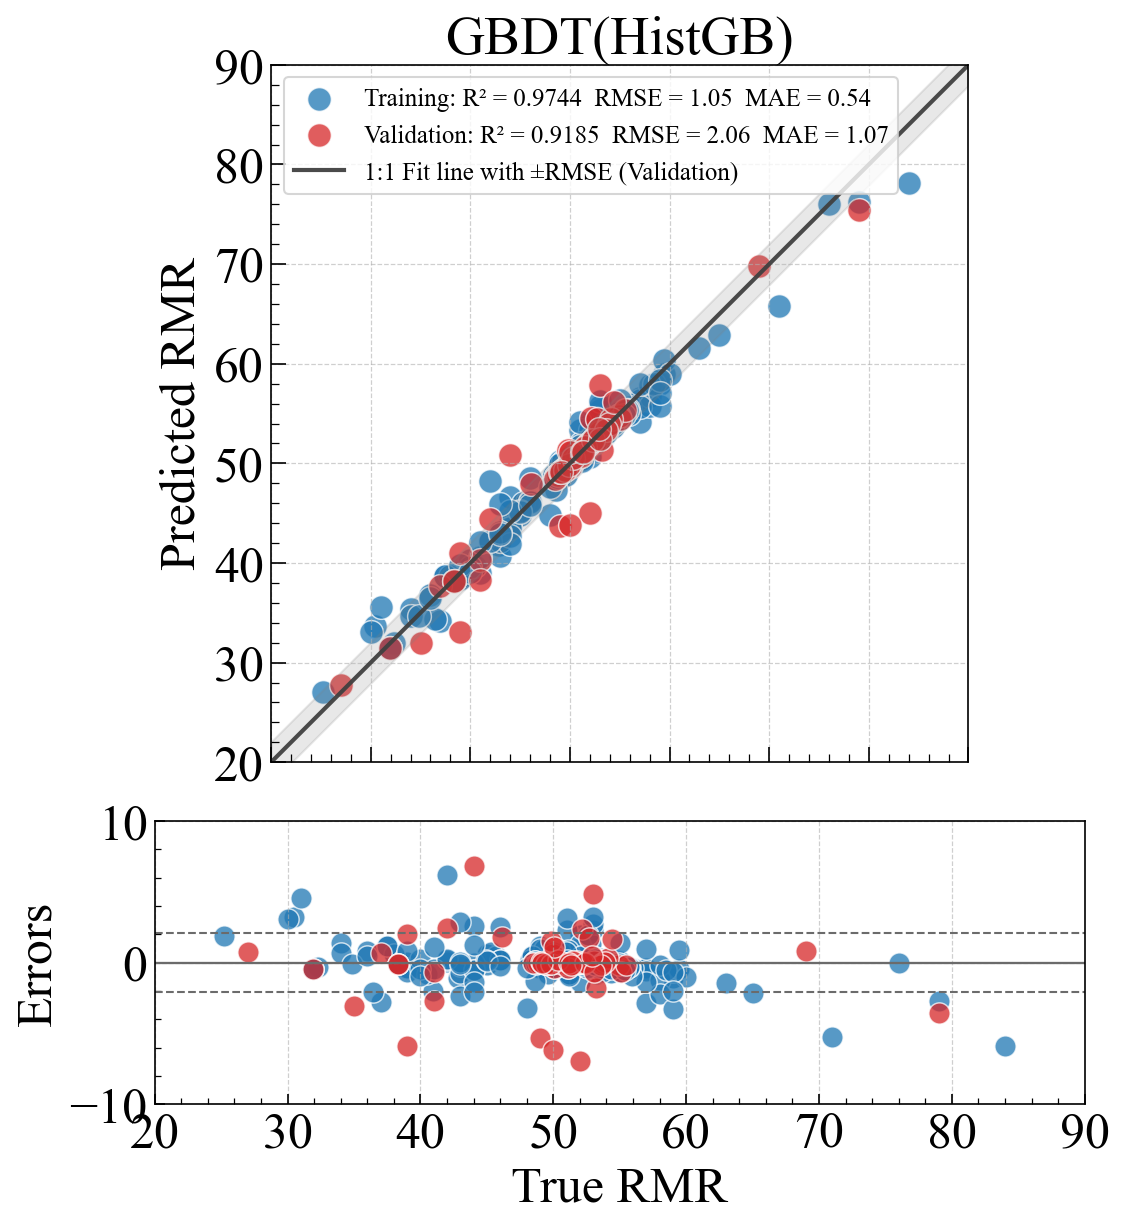

C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


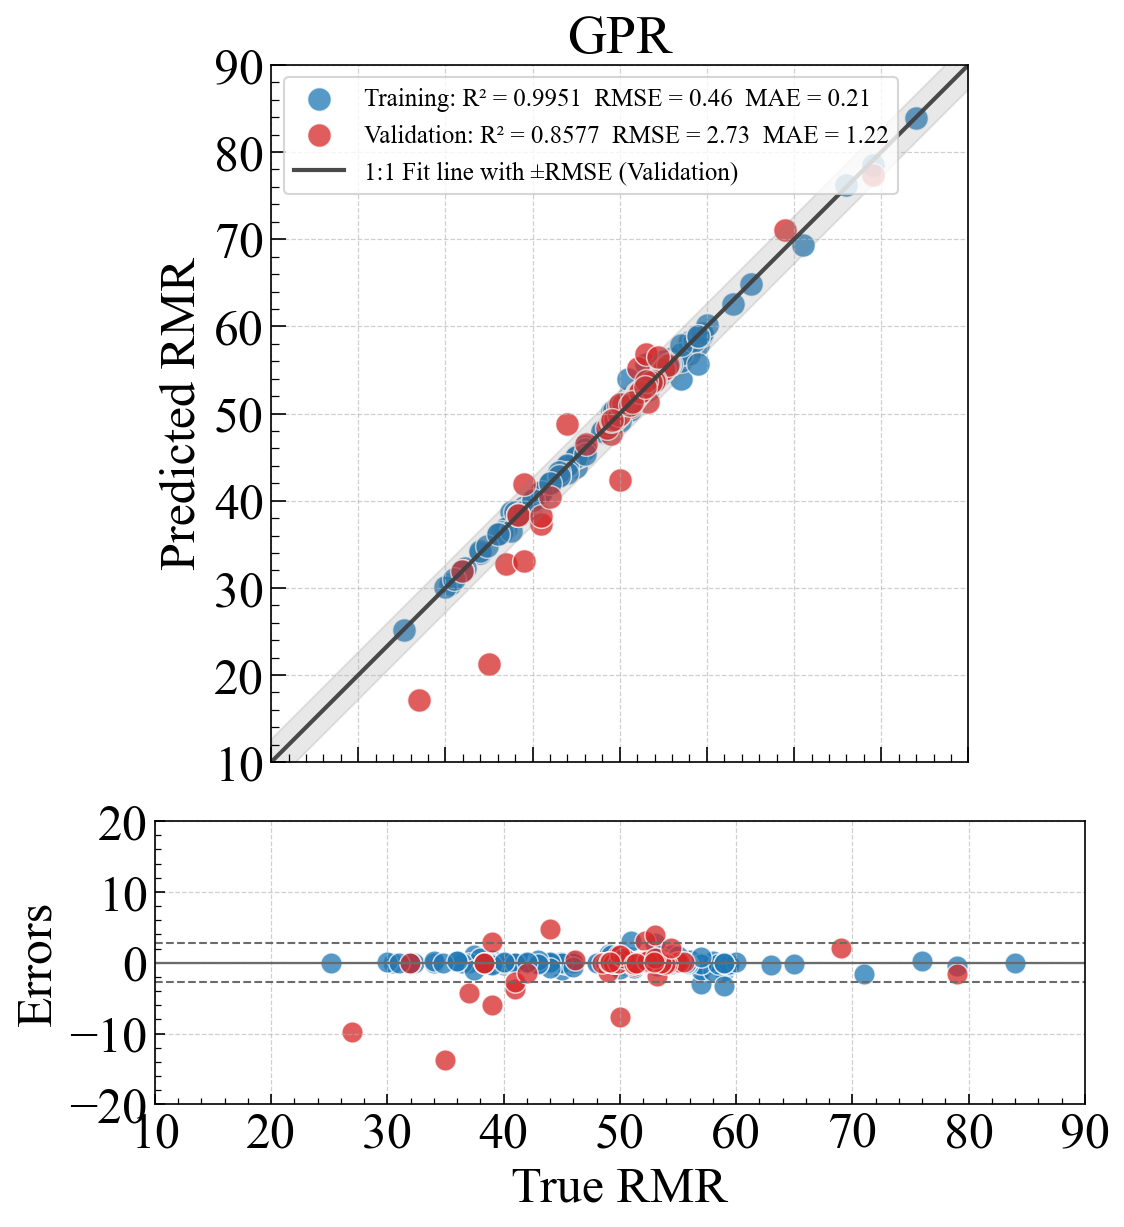

C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


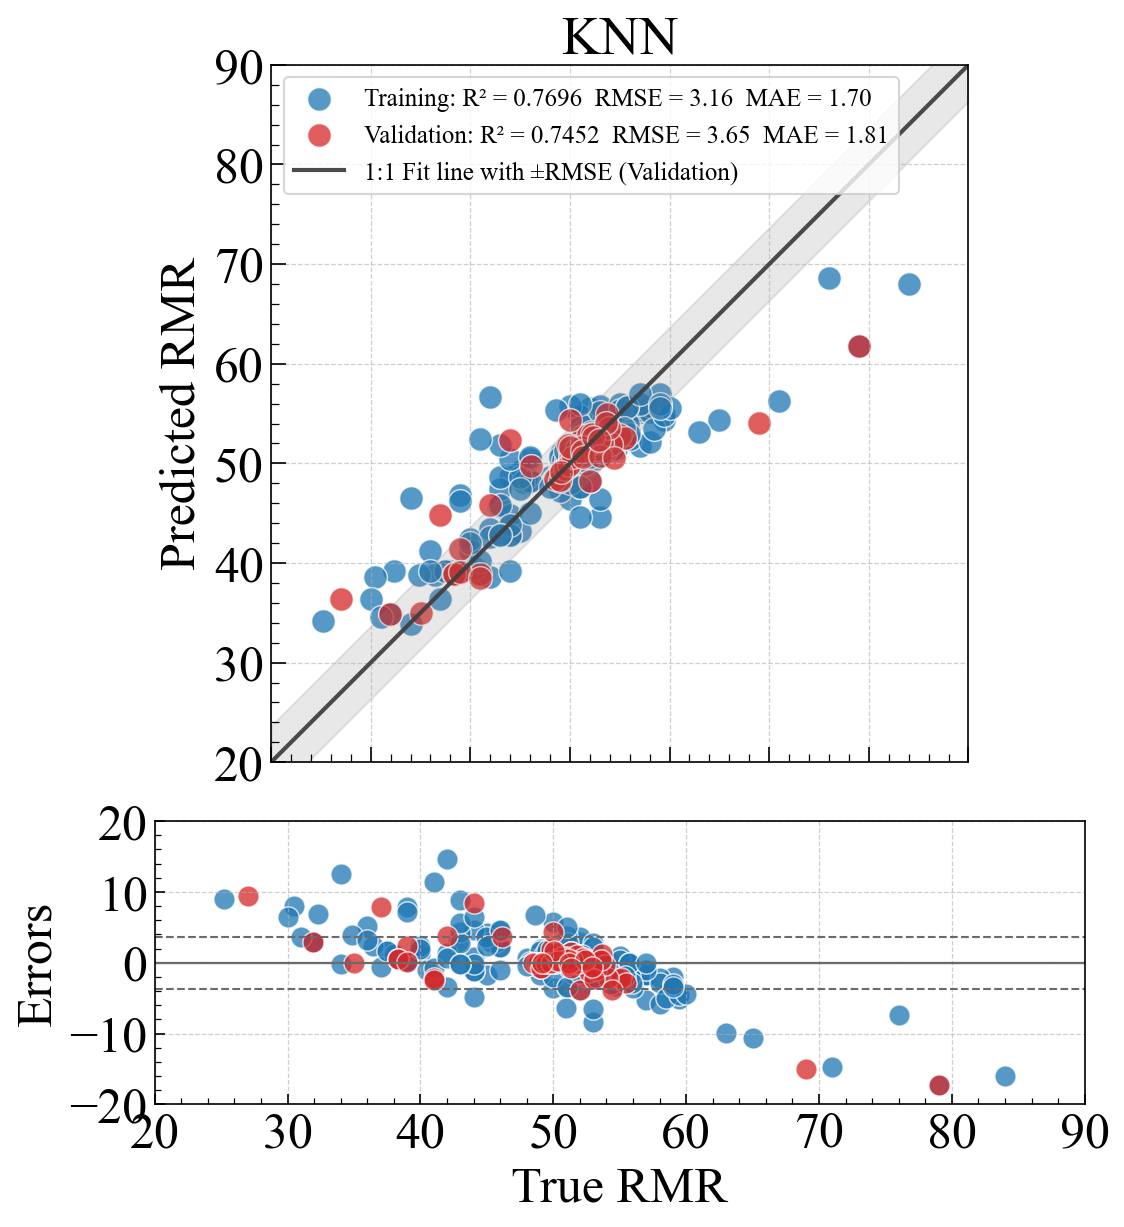

C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


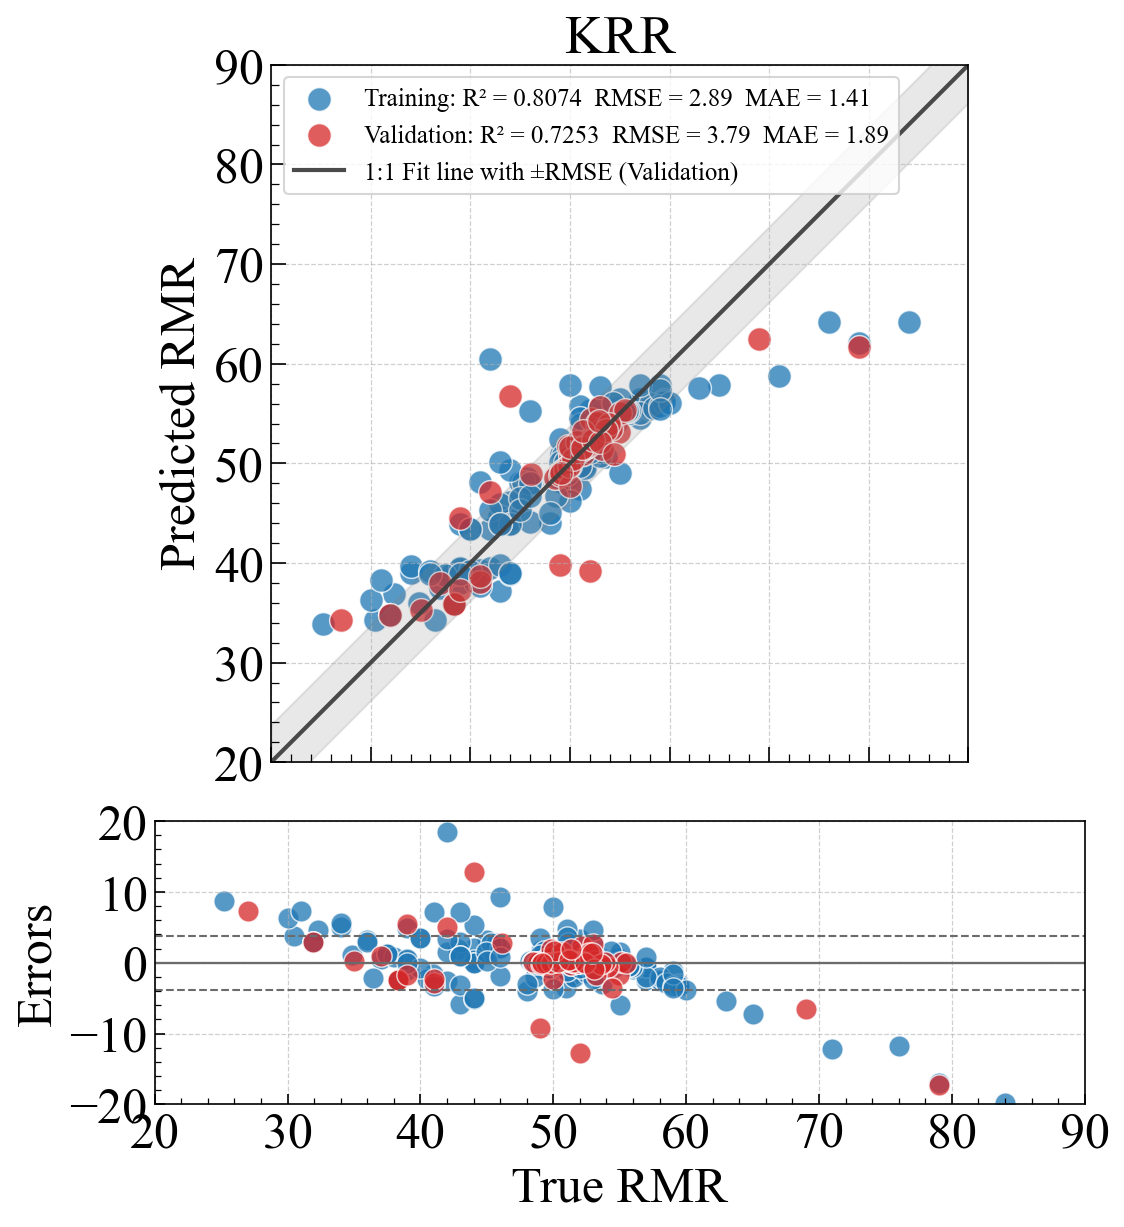

C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


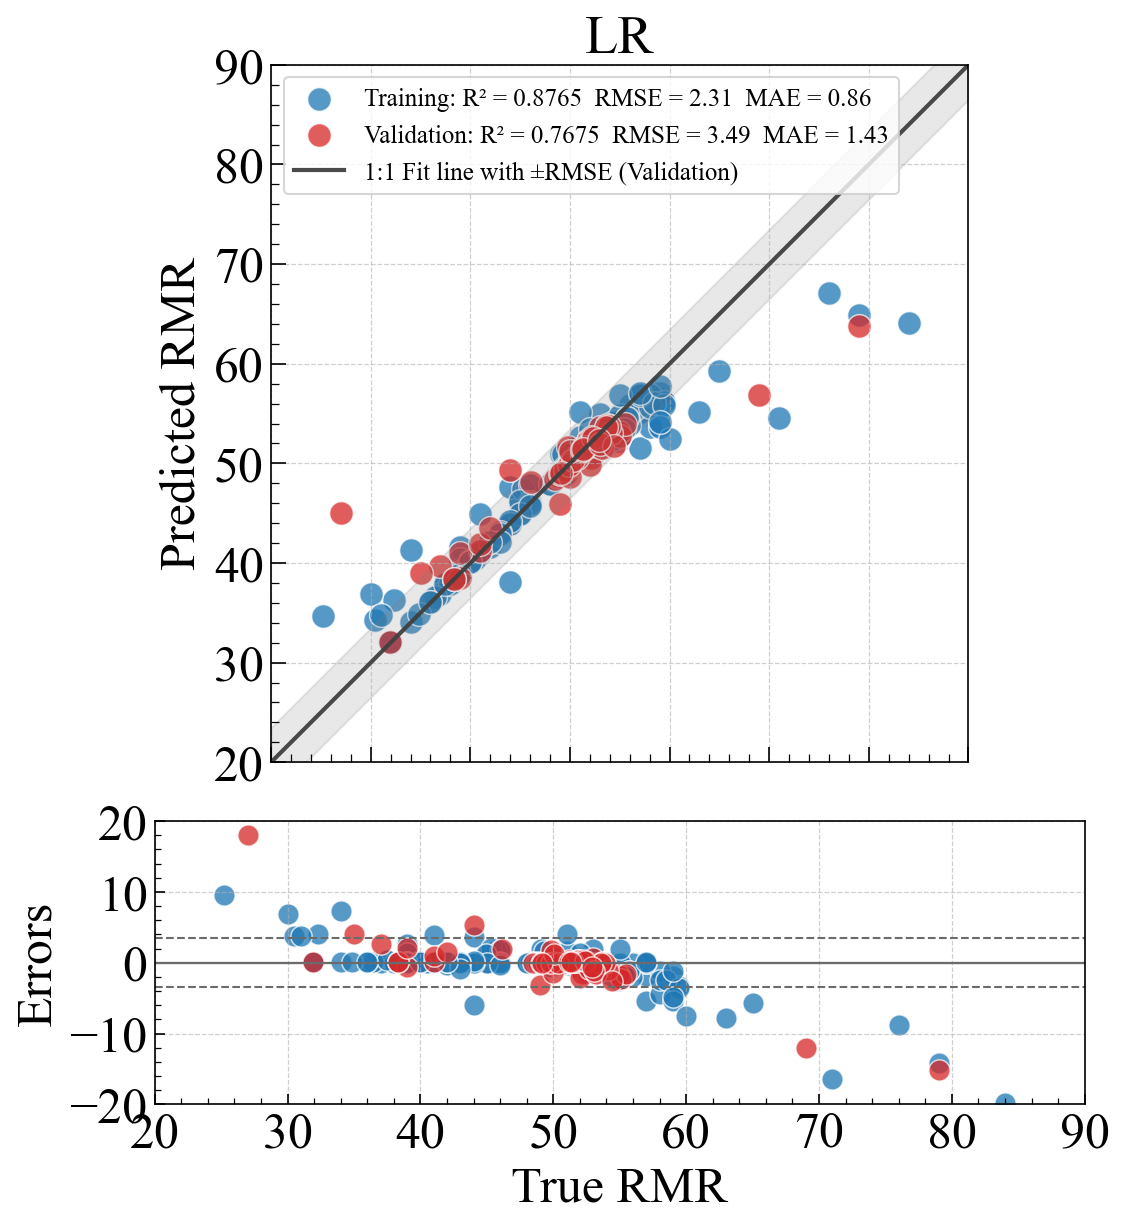

C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


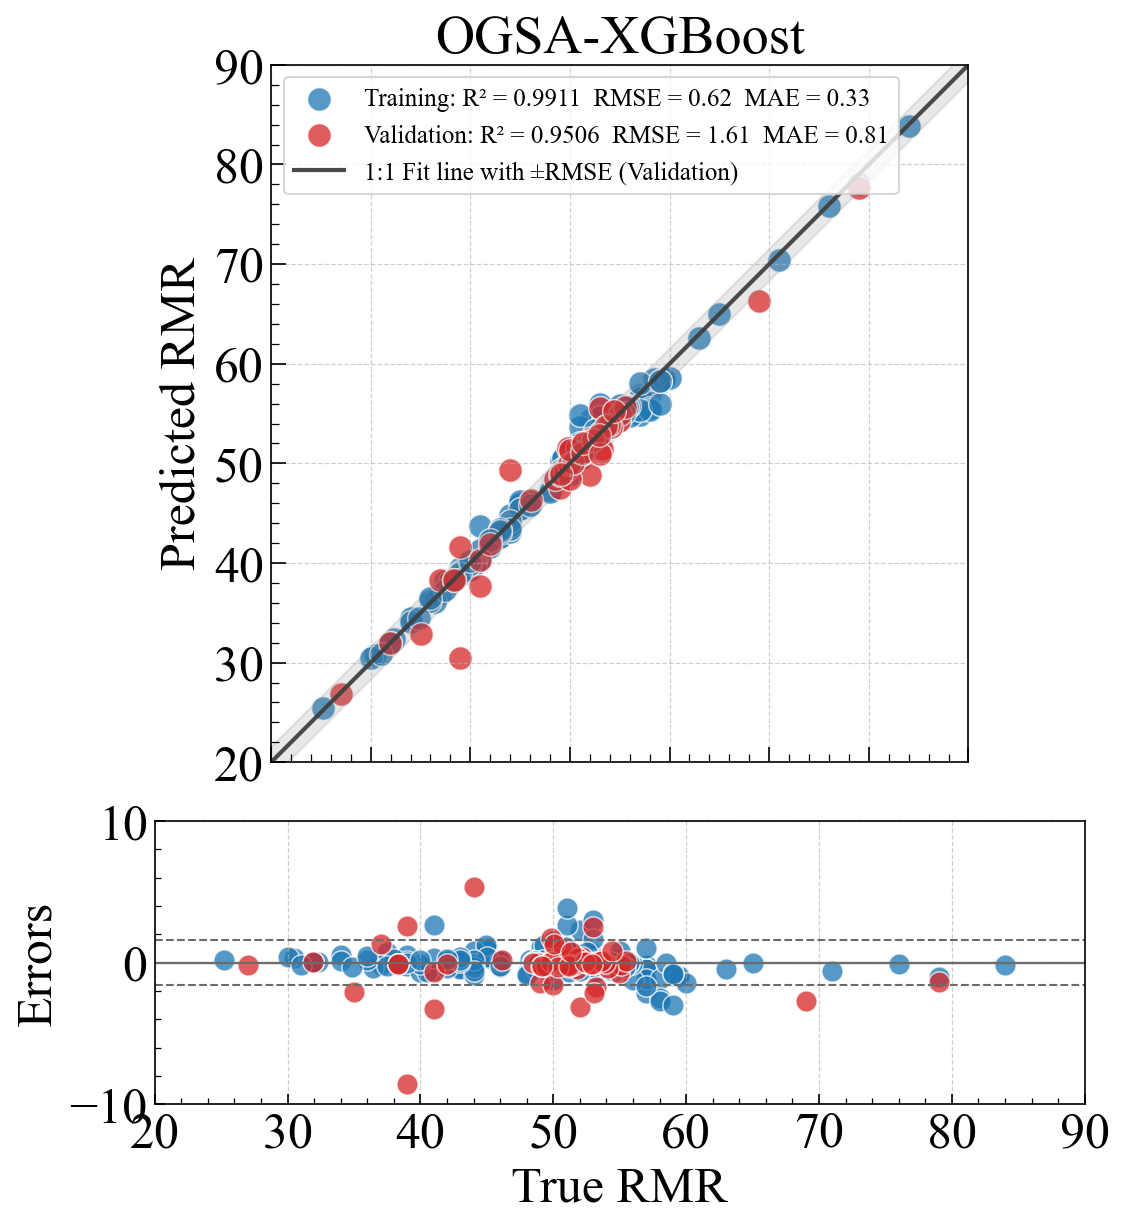

C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


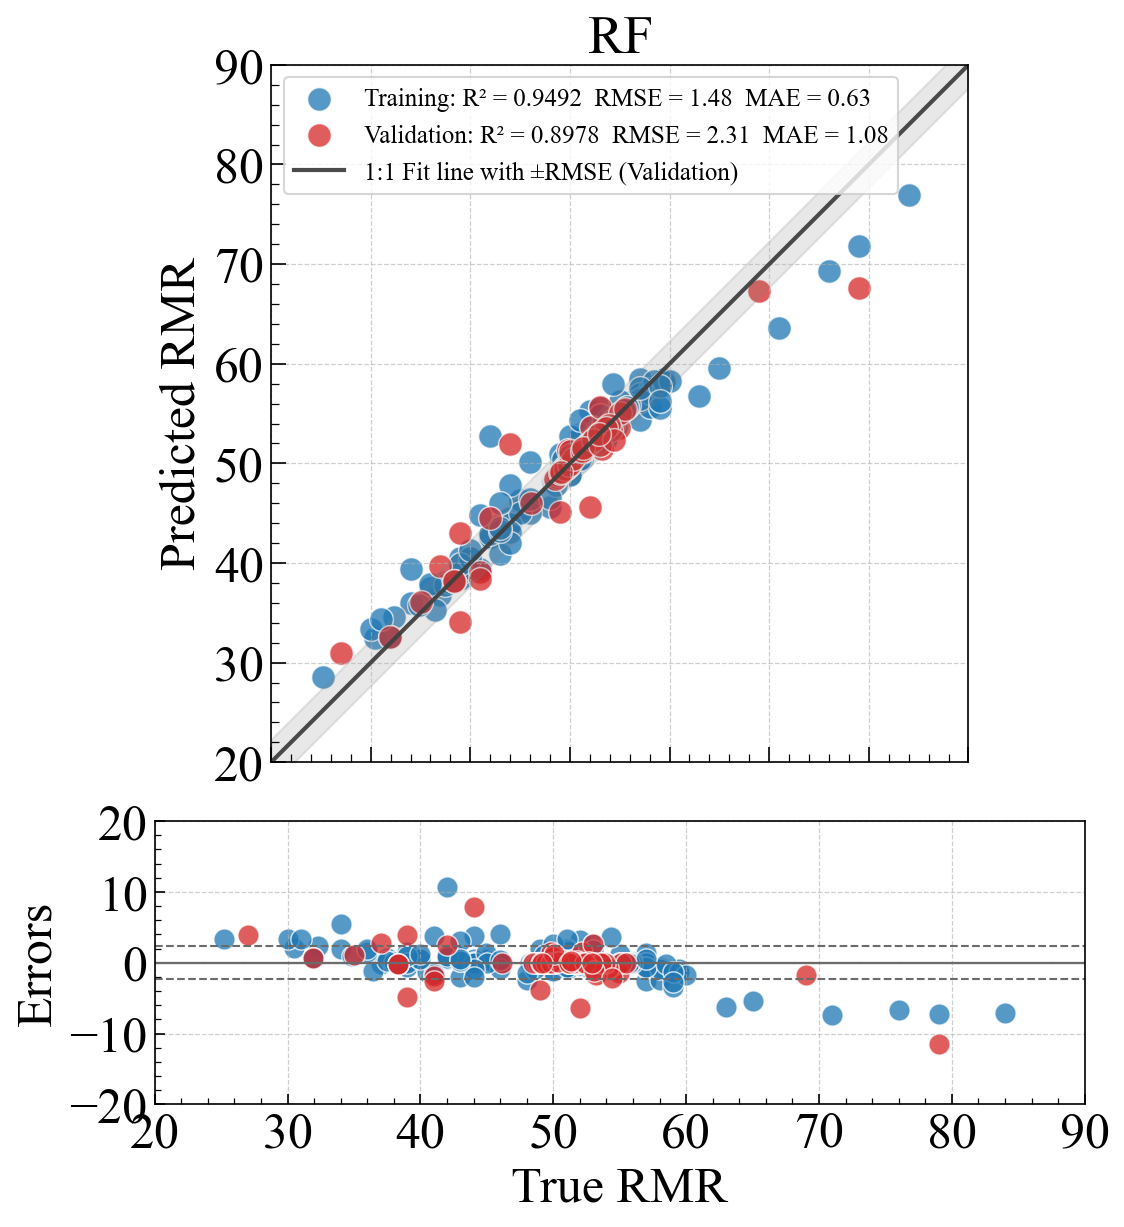

C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


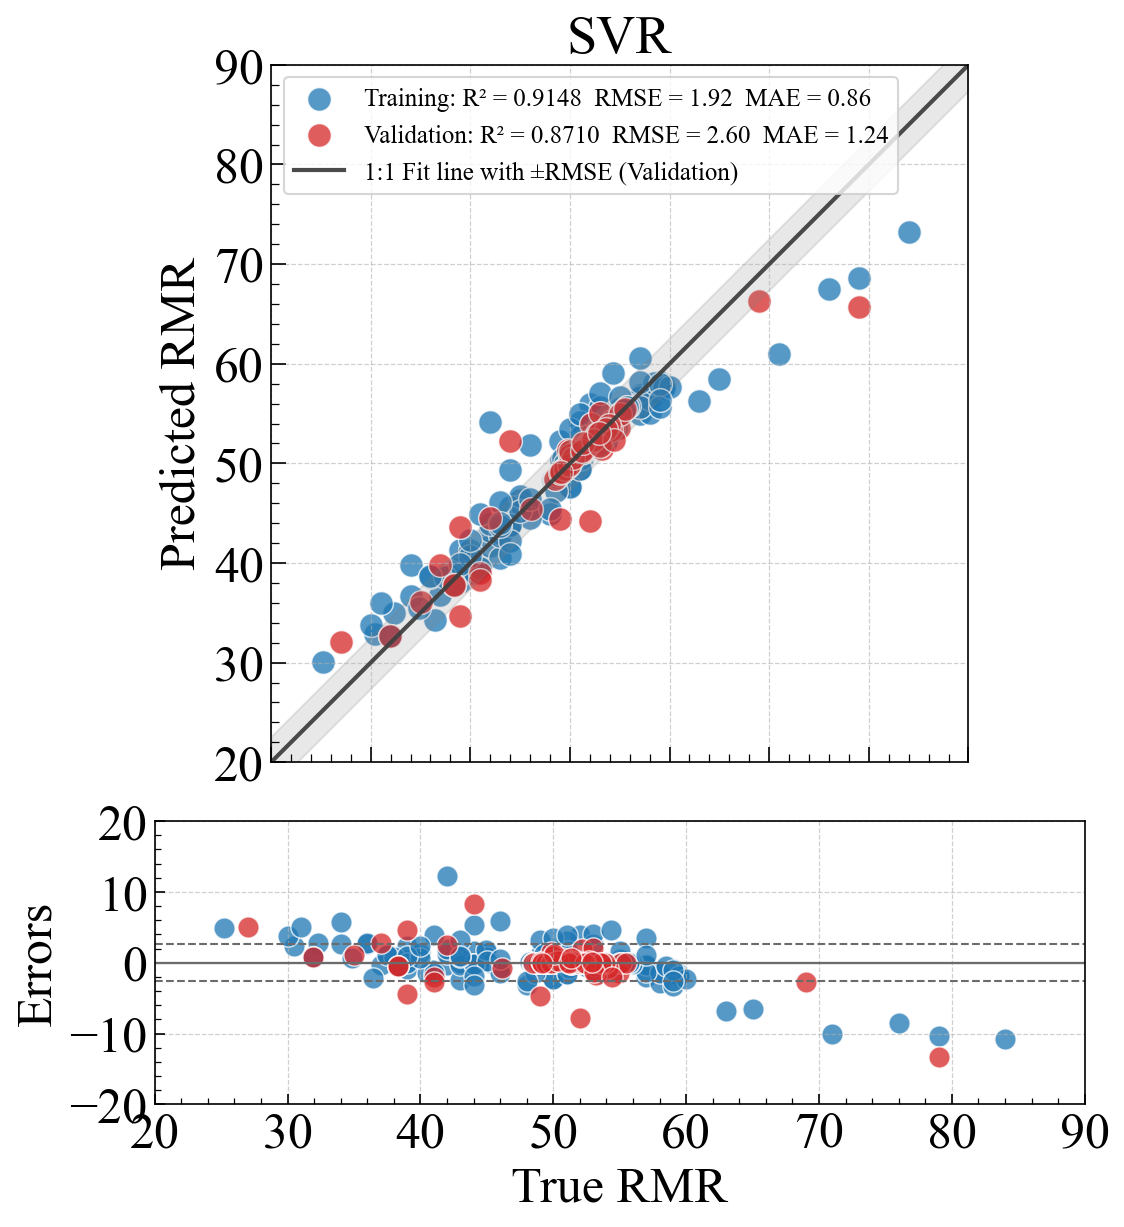

C:\Users\Mr Huang\AppData\Local\Temp\ipykernel_9332\1575895065.py:181: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


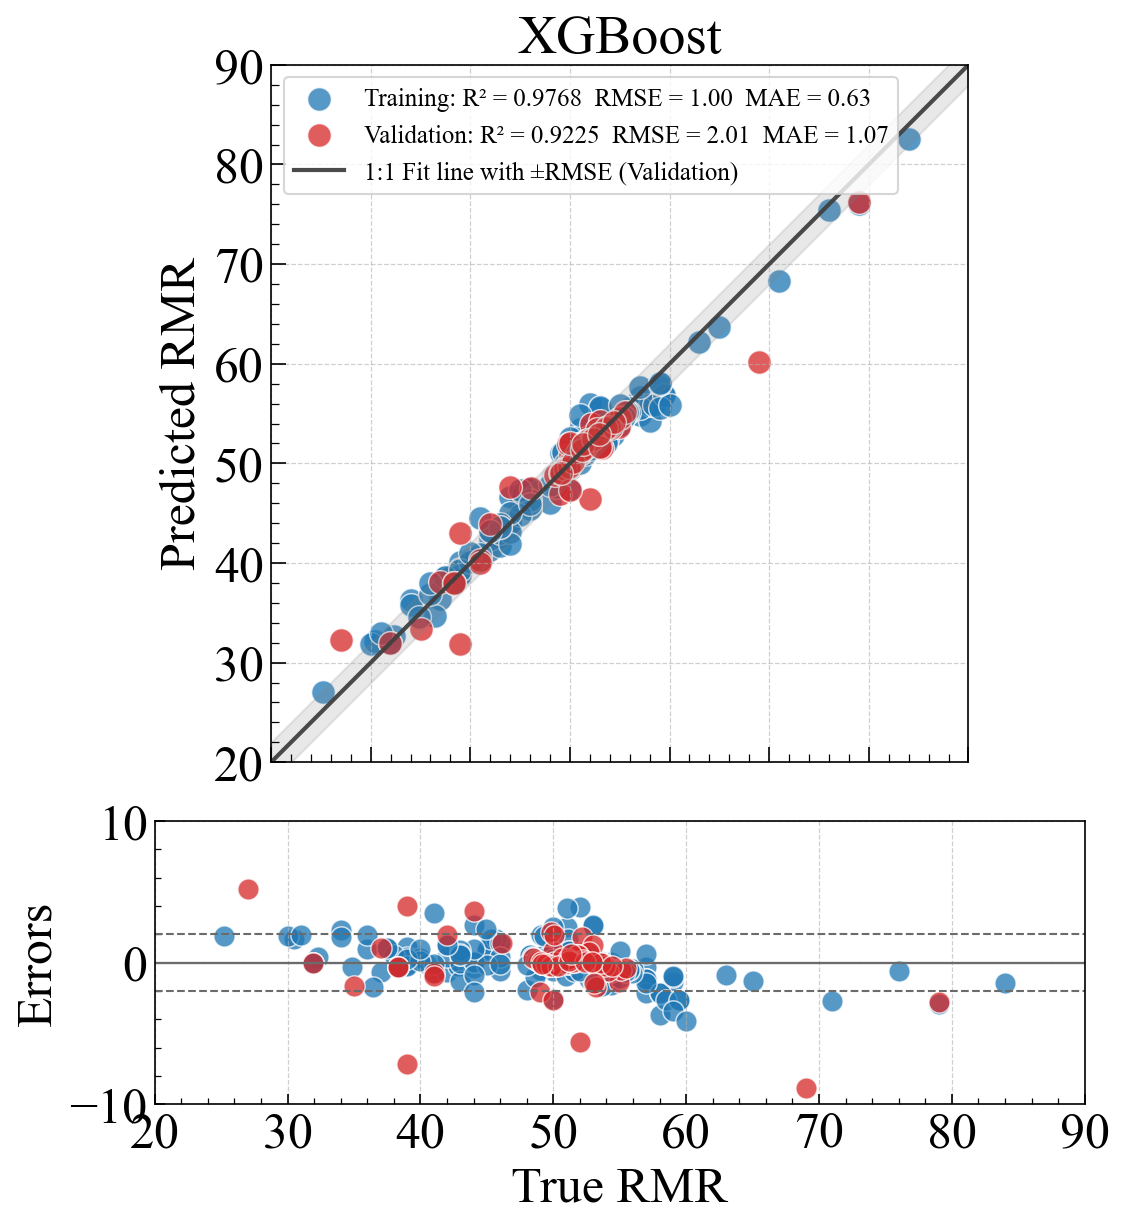

In [3]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

ROOT_IN = "RMR_Exports"

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 13,
    "axes.titlesize": 26,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "svg.fonttype": "none"
})

SPLIT_SHEETS = {"Train": "Sheet1", "Val": "Sheet2"}
SPLITS_TO_PLOT = ["Train", "Val"]

COLORS = {"Train": "#1f77b4", "Val": "#d62728"}
MARKER = "o"
SIZE = 130
ALPHA = 0.75
EDGECLR = "white"
EDGEW = 0.7

USE_RMSE_BAND = True
RMSE_BAND_SPLIT = "Val"

SUP2 = "\u00B2"

def _pick(df, wanted):
    m = {str(c).strip().lower(): c for c in df.columns}
    for k in wanted:
        if k in m:
            return m[k]
    return None

def _read_splits(xlsx_path):
    out = {}
    for split, sheet in SPLIT_SHEETS.items():
        try:
            df = pd.read_excel(xlsx_path, sheet_name=sheet)
        except Exception:
            return None
        c_true = _pick(df, ["rmr_true"])
        c_pred = _pick(df, ["rmr_pred"])
        if c_true is None or c_pred is None:
            return None
        sub = df[[c_true, c_pred]].rename(columns={c_true: "RMR_true", c_pred: "RMR_pred"})
        out[split] = sub.apply(pd.to_numeric, errors="coerce").dropna()
    return out

def _metrics(y_true, y_pred):
    if len(y_true) == 0:
        return float("nan"), float("nan"), float("nan")
    r2 = r2_score(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

def _find_all_model_excels(root):
    cand = set()
    cand.update(glob.glob(os.path.join(root, "**", "RMR_Predictions.xlsx"), recursive=True))
    cand.update(glob.glob(os.path.join(root, "**", "*.xlsx"), recursive=True))
    return sorted({p for p in cand if p.lower().endswith(".xlsx") and not os.path.basename(p).startswith("~$")})

def _nice_10_limits(vals):
    lo = float(np.nanmin(vals))
    hi = float(np.nanmax(vals))
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = 0.0, 1.0
    lo10 = 10 * math.floor(lo / 10.0)
    hi10 = 10 * math.ceil(hi / 10.0)
    if hi10 <= lo10:
        hi10 = lo10 + 10
    return lo10, hi10

def plot_one_model(model_name, splits):
    frames = []
    for k in SPLITS_TO_PLOT:
        if k in splits:
            frames.append(splits[k].assign(split=k))
    if not frames:
        return False
    all_df = pd.concat(frames, ignore_index=True)

    metrics = {}
    for sp in SPLITS_TO_PLOT:
        d = splits.get(sp, pd.DataFrame(columns=["RMR_true", "RMR_pred"]))
        metrics[sp] = _metrics(d["RMR_true"].values, d["RMR_pred"].values)

    lo, hi = _nice_10_limits(pd.concat([all_df["RMR_true"], all_df["RMR_pred"]], axis=0).values)

    fig = plt.figure(figsize=(8, 9), dpi=150)
    gs = GridSpec(2, 1, figure=fig, height_ratios=[3.2, 1.3], hspace=0.12)

    ax_main = fig.add_subplot(gs[0, 0])
    ax_res = fig.add_subplot(gs[1, 0], sharex=ax_main)

    for sp in SPLITS_TO_PLOT:
        if sp not in splits:
            continue
        d = splits[sp]
        label_name = "Training" if sp == "Train" else "Validation"
        r2, rmse, mae = metrics[sp]
        lbl = f"{label_name}: R{SUP2} = {r2:.4f}  RMSE = {rmse:.2f}  MAE = {mae:.2f}"
        ax_main.scatter(
            d["RMR_true"], d["RMR_pred"],
            s=SIZE, alpha=ALPHA, color=COLORS[sp], marker=MARKER,
            edgecolors=EDGECLR, linewidths=EDGEW, label=lbl
        )

    xx = np.linspace(lo, hi, 200)
    band_name = "Validation" if RMSE_BAND_SPLIT == "Val" else "Training"
    ax_main.plot(xx, xx, color="#404040", lw=2.0, alpha=0.95, label=f"1:1 Fit line with ±RMSE ({band_name})")
    if USE_RMSE_BAND and RMSE_BAND_SPLIT in metrics and np.isfinite(metrics[RMSE_BAND_SPLIT][1]):
        rmse_band = metrics[RMSE_BAND_SPLIT][1]
        ax_main.fill_between(xx, xx - rmse_band, xx + rmse_band, color="#808080", alpha=0.18)

    ax_main.set_xlim(lo, hi)
    ax_main.set_ylim(lo, hi)
    ax_main.set_aspect("equal", adjustable="box")
    ax_main.set_ylabel("Predicted RMR")
    ax_main.set_title(model_name)
    ax_main.grid(True, ls="--", lw=0.6, alpha=0.6)
    ax_main.xaxis.set_major_locator(MultipleLocator(10))
    ax_main.yaxis.set_major_locator(MultipleLocator(10))
    ax_main.minorticks_on()
    ax_main.tick_params(which="major", length=7, direction="in")
    ax_main.tick_params(which="minor", length=4, direction="in")
    ax_main.legend(frameon=True, loc="upper left")
    ax_main.tick_params(labelbottom=False)

    err_tr = splits["Train"]["RMR_pred"].values - splits["Train"]["RMR_true"].values
    err_va = splits["Val"]["RMR_pred"].values - splits["Val"]["RMR_true"].values

    ax_res.scatter(
        splits["Train"]["RMR_true"], err_tr, s=SIZE * 0.8,
        color=COLORS["Train"], alpha=ALPHA, edgecolors=EDGECLR, linewidths=EDGEW
    )
    ax_res.scatter(
        splits["Val"]["RMR_true"], err_va, s=SIZE * 0.8,
        color=COLORS["Val"], alpha=ALPHA, edgecolors=EDGECLR, linewidths=EDGEW
    )

    ax_res.axhline(0.0, color="#6b6b6b", lw=1.1)
    if RMSE_BAND_SPLIT in metrics and np.isfinite(metrics[RMSE_BAND_SPLIT][1]):
        r = metrics[RMSE_BAND_SPLIT][1]
        ax_res.axhline(+r, color="#6b6b6b", lw=1.0, ls="--")
        ax_res.axhline(-r, color="#6b6b6b", lw=1.0, ls="--")

    emax = np.nanmax(np.abs(np.r_[err_tr, err_va, metrics[RMSE_BAND_SPLIT][1] if RMSE_BAND_SPLIT in metrics else 0]))
    if not np.isfinite(emax) or emax <= 1e-12:
        emax = 1.0
    eylim = 10 * math.ceil(emax / 10.0)

    ax_res.set_xlim(lo, hi)
    ax_res.set_ylim(-eylim, eylim)
    ax_res.set_xlabel("True RMR")
    ax_res.set_ylabel("Errors")
    ax_res.grid(True, ls="--", lw=0.6, alpha=0.6)
    ax_res.xaxis.set_major_locator(MultipleLocator(10))
    ax_res.yaxis.set_major_locator(MultipleLocator(10))
    ax_res.minorticks_on()
    ax_res.tick_params(which="major", length=5, direction="in")
    ax_res.tick_params(which="minor", length=3, direction="in")

    fig.tight_layout()
    plt.show()
    return True

def main():
    xlsx_paths = _find_all_model_excels(ROOT_IN)
    if not xlsx_paths:
        return
    for p in xlsx_paths:
        parent = os.path.basename(os.path.dirname(p))
        model_name = parent if parent and parent.lower() != "rmr_exports" else os.path.splitext(os.path.basename(p))[0]
        splits = _read_splits(p)
        if splits is None or "Train" not in splits or "Val" not in splits:
            continue
        plot_one_model(model_name, splits)

if __name__ == "__main__":
    main()